# Plot Raster Intersection Maps

This notebook provides the code to create maps showing new power plant sitings under high renewables and business-as-usual scenarios plotted on top of raster data of three areas of interest. The three raster types included are: disadvantaged communities, important farmland, and proximity to natural areas.

## Imports

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely
from shapely import Point

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import rasterio
from rasterio.plot import show

import seaborn as sns

import os
from pathlib import Path

### Settings

In [2]:
# list of scenarios for analysis
scenario_list = ['high_renewables', 'business_as_usual']

# list of years for analysis
year = 2050

# coordinates and labels for specified cities
city_label_data = {
    'city': ['Albuquerque', 'San Francisco', 'Los Angeles', 'Portland', 'Seattle', 'Phoenix', 'Salt Lake City', 'Denver', 'Boise',
              "Billings", "Cheyenne", "Las Vegas"], 
    'Latitude': [35.0853336,  37.7749295, 34.0522342, 45.5230622, 47.6062095, 33.4483771, 40.7607793, 39.7392358, 43.6187102, 
                  45.7832856, 41.1399814,  36.1699412],  
    'Longitude': [-106.6055534, -122.4194155,  -118.2436849, -122.6764816, -122.3320708,-112.0740373,-111.8910474, -104.990251, -116.2146068, 
                   -108.5006904,-104.8202462, -115.1398296]}

west_states = ['washington', 'oregon', 'california', 'idaho', 'montana', 'new_mexico', 'arizona', 'utah', 'nevada', 'colorado', 'wyoming']

retired_color = '#631200'
unsuitable_color = "#f3f2f2"
suitable_color = "#d9dede"

layer_cmap = ListedColormap([suitable_color, unsuitable_color])

color_map_dict={
            'Natural Gas':'#bdb59d',
            'Coal': '#75736d',
            'Solar PV': '#F7B615',
            'Solar CSP': '#f1781b',
            'Wind': '#95C060', 
            'Nuclear': '#6D547C', 
            'Offshore Wind':'#2B7F9E', 
            'Biomass': '#713275',
            'Geothermal': '#BB3B1C', 
            'Oil': '#BB3B1C',
            'Hydro': '#14345e'}

markersize = 8

# create map legend elements
natgas = Line2D([0], [0], lw=0, markersize=markersize, label='Natural Gas',marker='o', 
                markerfacecolor=color_map_dict['Natural Gas'], markeredgecolor=color_map_dict['Natural Gas'])
solar_pv = Line2D([0], [0], lw=0, markersize=markersize, label='Solar PV',marker='o', 
                  markerfacecolor=color_map_dict['Solar PV'], markeredgecolor=color_map_dict['Solar PV'])
solar_csp = Line2D([0], [0], lw=0, markersize=markersize, label='Solar CSP',marker='o', 
                   markerfacecolor=color_map_dict['Solar CSP'], markeredgecolor=color_map_dict['Solar CSP'])
wind = Line2D([0], [0], lw=0, markersize=markersize,label='Wind',marker='o', 
              markerfacecolor=color_map_dict['Wind'], markeredgecolor=color_map_dict['Wind'])
wind_off = Line2D([0], [0], lw=0, markersize=markersize, label='Offshore Wind',marker='o', 
                  markerfacecolor=color_map_dict['Offshore Wind'], markeredgecolor=color_map_dict['Offshore Wind'])
coal= Line2D([0], [0], lw=0, markersize=markersize, label='Coal',marker='o', 
             markerfacecolor=color_map_dict['Coal'], markeredgecolor=color_map_dict['Coal'])
biomass = Line2D([0], [0], lw=0, markersize=markersize, label='Biomass',marker='o', 
                 markerfacecolor=color_map_dict['Biomass'], markeredgecolor=color_map_dict['Biomass'])
geothermal = Line2D([0], [0], lw=0, markersize=markersize, label='Geothermal',marker='o', 
                    markerfacecolor=color_map_dict['Geothermal'], markeredgecolor=color_map_dict['Geothermal'])
hydro = Line2D([0], [0], lw=0, markersize=markersize, label='Hydro',marker='o', 
               markerfacecolor=color_map_dict['Hydro'], markeredgecolor=color_map_dict['Hydro'])

retired = Line2D([0], [0], lw=0, markersize=markersize, label='Retired Power Plants',marker='x', color=retired_color)
volt = Line2D([0], [0], color='black', lw=1, label='Transmission >250kV')

legend_elements = [coal, natgas, biomass, geothermal,solar_csp, solar_pv, wind, wind_off, hydro, retired, volt]
short_legend_elements = [coal, natgas, biomass, solar_csp, solar_pv, wind, wind_off,retired, volt]

# dictionary of DAC layers with their simple names
dac_dict = {'gridcerf_usceq_cejst_exclude_all_dacs.tif': 'DACs',
            'gridcerf_usceq_cejst_exclude_energy_dacs.tif': 'Energy DACs',
            'gridcerf_usceq_cejst_exclude_transportation_dacs.tif': 'Transportation DACs',
            'gridcerf_usceq_cejst_exclude_housing_dacs.tif':'Housing DACs',
            'gridcerf_usceq_cejst_exclude_pollution_dacs.tif':'Pollution DACs',
            'gridcerf_usceq_cejst_exclude_health_dacs.tif':'Health DACs',
            'gridcerf_usceq_cejst_exclude_climate_dacs.tif':'Climate DACs',
            'gridcerf_usceq_cejst_exclude_workforce_dacs.tif':'Workforce DACs',
            'gridcerf_usceq_cejst_exclude_water_dacs.tif':'Water DACs'}

# dictionary of important farmland layers with their simple names
farm_dict = {'gridcerf_usda_combined_important_farmland.tif': 'Important Farmland',
            'gridcerf_usda_nrsc_prime_farmland_classification.tif': 'Prime Farmland',
            'gridcerf_usda_nrsc_farmland_of_state_importance.tif': 'Farmland of State Importance',
            'gridcerf_usda_nrsc_farmland_of_local_importance.tif':'Farmland of Local Importance',
            'gridcerf_usda_nrsc_farmland_of_unique_importance.tif':'Farmland of Unique Importance'}

# dictionary of environmental layers with their simple names
env_dict = {'gridcerf_combined_environment_level_1_1buff.tif': 'Within 1 km of Natural Area',
           'gridcerf_combined_environment_level_1_5buff.tif': 'Within 5 km of Natural Area',
           'gridcerf_combined_environment_level_1_10buff.tif': 'Within 10 km of Natural Area',
           }

### Collect Data Paths

In [3]:
# data dir
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'input_data')

# output figure dir
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

# western interconnection shapefile
wecc_shp_path =  os.path.join(data_dir, "wecc_boundary_shp", "wecc_boundary.shp")

# western interconnection transmission shapefile
transmission_path = os.path.join(data_dir, 'wecc_transmission_shp', 'wecc_transmission_250kv.shp')

# infrastructure siting output csv
infrastucture_path = os.path.join(data_dir, 'infrastructure_data_csv', 'infrastructure_data.csv')

# land area files
land_area_raster_dir = os.path.join(data_dir, "west_raster_data", 'land_area')

# all area files
all_area_raster_dir = os.path.join(data_dir, "west_raster_data", 'all_area')

### Functions

In [4]:
def results_to_geodataframe(df, crs = "ESRI:102003"):
    """ 
    Takes a pandas DataFrame with x and y coordinates as input and 
    converts to a GeoPandas GeodataFrame. Coordinates in DataFrame are expected to
    follow the ESRI:102003 albers equal area conic coordinate referece system.
    x-coordinate column should be called 'xcoord', y-coordinate column should be
    called 'ycoord'

    :param df:        input Pandas DataFrame with x/y coordinates
    :type df:         Pandas DataFrame
    
    :param crs:       Coordinate reference system to use for GeoDataFrame
    :type crs:        str
    
    """
    
    # create geometry column from coordinate fields
    geometry = [Point(xy) for xy in zip(df['xcoord'], df['ycoord'])]
    
    gdf = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)
    
    return gdf


def plot_map(gdf, scenario, city_gdf, year, title, output_file_name, layer_path=None, layer_name=None, all_operational=False):
    """
    Maps power plant sitings for given scenario and run year. All CERF-sited power plants by
    given run year will be sited along with all power plants that were retired up to the same year.
    If the all_operational parameter is set to True, this function will also plot all power plants
    that are operational in the given year, both CERF-sited and non CERF-sited (i.e., pre-existing infrastructure.
    The resulting map is save as a png file to the figures folder.

    :param gdf:                       Geopandas GeoDataFrame of power plants (new cerf sited, non-cerf sited operational, and non-cerf sited retired)
    :type gdf:                        geopandas.GeoDataFrame
    
    :param scenario:                  Name of scenario to plot
    :type scenario:                   str

    :param city_gdf:                  Geopandas GeoDataFrame of major city locations
    :type city_gdf:                   geopandas.GeoDataFrame

    :param year:                      Year that values should be plotted for
    :type year:                       int  

    :param title:                     Plot title
    :type title:                      str  

    :param output_file_name:          Name of file to save output image as
    :type output_file_name:           str  

    :param all_operational:           If True, all operational plants are plotted. If False, only new infrastructure and retired plants are plotted.
    :type all_operational:            bool     

    """
    
    
    # set figure size
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_axis_off();

    # create a layer patch for the layer name
    layer_patch = mpatches.Patch(color = suitable_color, label = layer_name)
    legend_elements_copy = legend_elements.copy()
    legend_elements_copy.append(layer_patch)
    
    with rasterio.open(layer_path) as src:
        show(src, ax=ax, cmap=layer_cmap)
        wecc_shp.boundary.plot(ax=ax, color = 'black')
        
        # plot cerf-sited plants
        gdf_cerf = gdf[(gdf.cerf_sited == 1) & (gdf.scenario == scenario)]
        gdf_cerf.plot(ax=ax, markersize=12,  marker = 'o', lw=.3, facecolor=gdf_cerf['tech_name_simple'].map(color_map_dict))
    
        # plot retired plants
        gdf[(gdf.retirement_year <= year) & (gdf.scenario == scenario)].plot(ax=ax, markersize=25, color=retired_color, marker="x")
        if all_operational:
            gdf_op = gdf[(gdf.retirement_year > year) & (gdf.scenario == scenario) & (gdf.cerf_sited == 0)].copy()
            gdf_op.plot(ax=ax, markersize=12,  marker = 'o', lw=.3, facecolor=gdf_op['tech_name_simple'].map(color_map_dict))
        else:
            pass
        
        # plot transmission line
        transmission_shp.plot(ax=ax, color='black', lw=.75)
    
        # plot city locations
        city_gdf.plot(ax=ax, color='black')


        # add city labels
        for x, y, label in zip(city_gdf.geometry.x, city_gdf.geometry.y, city_gdf.city):
            ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", ha='right', size=12)

        # add legend
        plt.legend(handles=short_legend_elements, fontsize=12, title_fontsize = 12, loc='lower left', ncol=1, facecolor='white')
        
    # add title
    plt.title(title, size=20)

    plt.tight_layout()

    # save figure to folder
    plt.savefig(os.path.join(fig_dir, output_file_name))
    
    return plt.show()


### Collect Data

In [5]:
# read in wecc shapefile
wecc_shp = gpd.read_file(wecc_shp_path)

# read in wecc transmission shapefile
transmission_shp = gpd.read_file(transmission_path)

# collect infrastructure data
df = pd.read_csv(infrastucture_path)

# reduce to year of interest
df = df[df.sited_year <= year]

### Create Geodataframes

In [6]:
# create geodataframe from infrastucture data
gdf = results_to_geodataframe(df=df)
gdf = gdf[gdf.region_name.isin(west_states)]

# create a geodataframe of major cities to plot
city_df = pd.DataFrame.from_dict(city_label_data)
city_gdf = gpd.GeoDataFrame(city_df, geometry=gpd.points_from_xy(city_df.Longitude, city_df.Latitude), crs="EPSG:4326")
city_gdf.to_crs('ESRI:102003', inplace=True)

________________

## Figure 3 - Power Plant Additions and Retirements by 2050 and their Intersections with Areas of Interest, high renewables 

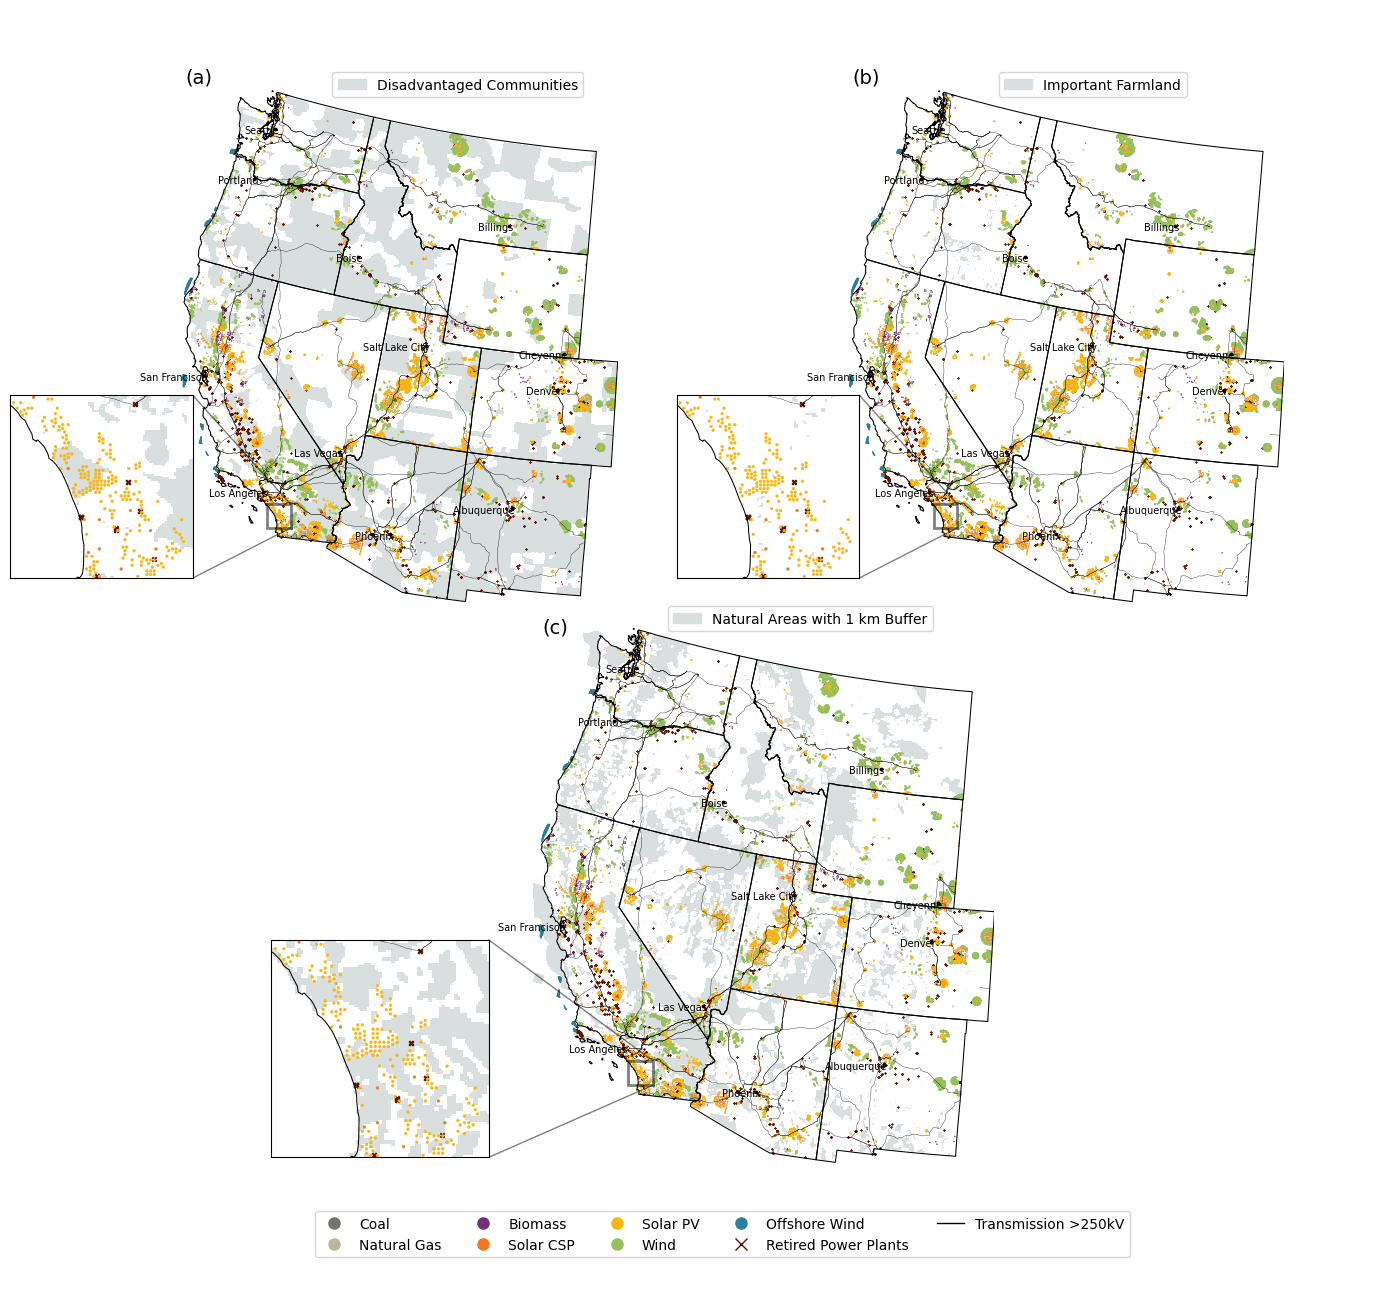

In [7]:
scenario = 'high_renewables'

year = 2050

# figure plot
layer_list = [os.path.join(land_area_raster_dir, 'gridcerf_usceq_cejst_exclude_all_dacs.tif'), 
              os.path.join(land_area_raster_dir, 'gridcerf_usda_combined_important_farmland.tif'),
              os.path.join(all_area_raster_dir, 'gridcerf_combined_environment_level_1_1buff.tif')]

# create a layer patch for the layer name
legend_elements_copy = short_legend_elements.copy()
gdf_plot = gdf[gdf.scenario == scenario]

height = 13
width = 14

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=6, 
                nrows=4,
                width_ratios=[.15,.15, .15, .15 ,.15, .15], 
                wspace=0,
                hspace=0,
                height_ratios=[.05, .5, .5,.08])

ax_title = fig.add_subplot(spec[0,:])
ax1a =fig.add_subplot(spec[1,0:3])
ax1b =fig.add_subplot(spec[1,3:])
ax2a =fig.add_subplot(spec[2,1:5])
ax_legend = fig.add_subplot(spec[3,:])

ax_objs = [ax1a, ax1b, ax2a]
gdf_cerf = gdf_plot[(gdf_plot.cerf_sited == 1)]
gdf_all = gdf_plot.copy()
i = 0
for a in ax_objs:
    with rasterio.open(layer_list[i]) as src:
        show(src, ax=a, cmap=layer_cmap)
        wecc_shp.boundary.plot(ax=a, color = 'black', lw=.75)

         # plot retired plants
        gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
        gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
        gdf_ret_plot.plot(ax=a, markersize=.5, color=retired_color, marker="x")

        gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
        gdf_plot.plot(ax=a, markersize=.5,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))

        transmission_shp.plot(ax=a, color='black', lw=.25)
        city_gdf.plot(ax=a, color='black', markersize=3)
    
        # add city labels
        for x, y, label in zip(city_gdf.geometry.x, city_gdf.geometry.y, city_gdf.city):
            a.annotate(label, xy=(x, y), xytext=(3, -3), textcoords="offset points", ha='right', size=7)

    i+=1
    a.set_axis_off()
ax_legend.legend(handles=legend_elements_copy, fontsize=10, loc='center', ncol=5, facecolor='white')
ax_legend.set_axis_off()
ax_title.set_axis_off()

ax1a.annotate('(a)' , xy=(-2.35e6, 1.6e6), ha='left', size=14)
ax1b.annotate('(b)' , xy=(-2.35e6, 1.6e6), ha='left', size=14)
ax2a.annotate('(c)' , xy=(-2.35e6, 1.55e6), ha='left', size=14)


ax1a.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Disadvantaged Communities')], bbox_to_anchor=(.36, 1.0), )
ax1b.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Important Farmland')], bbox_to_anchor=(.36, 1.0), )
ax2a.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Natural Areas with 1 km Buffer')], bbox_to_anchor=(.9, 1.05), )

plt.tight_layout()

# inset Axes
x1, x2, y1, y2 = -2e6, -1.9e6, -.3e6, -.2e6  # subregion of the original image
axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin1 = ax2a.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax2a.indicate_inset_zoom(axin1, edgecolor="black", lw=2) 

axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin2 = ax1a.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax1a.indicate_inset_zoom(axin2, edgecolor="black", lw=2) 

axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin3 = ax1b.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax1b.indicate_inset_zoom(axin3, edgecolor="black", lw=2) 

# top left axin
with rasterio.open(layer_list[0]) as src:
    show(src, ax=axin2, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin2, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin2, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin2, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin2, color='black', lw=.25)
axin2.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 

# top left axin
with rasterio.open(layer_list[1]) as src:
    show(src, ax=axin3, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin3, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin3, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin3, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin3, color='black', lw=.25)
axin3.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 


# bottom axin
with rasterio.open(layer_list[2]) as src:
    show(src, ax=axin1, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin1, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin1, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin1, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin1, color='black', lw=.25)
axin1.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 

output_file_name = 'fig_3_high_renewables_sitings_and_layers_2050.png'
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, output_file_name), dpi=700)

plt.show()

_________________

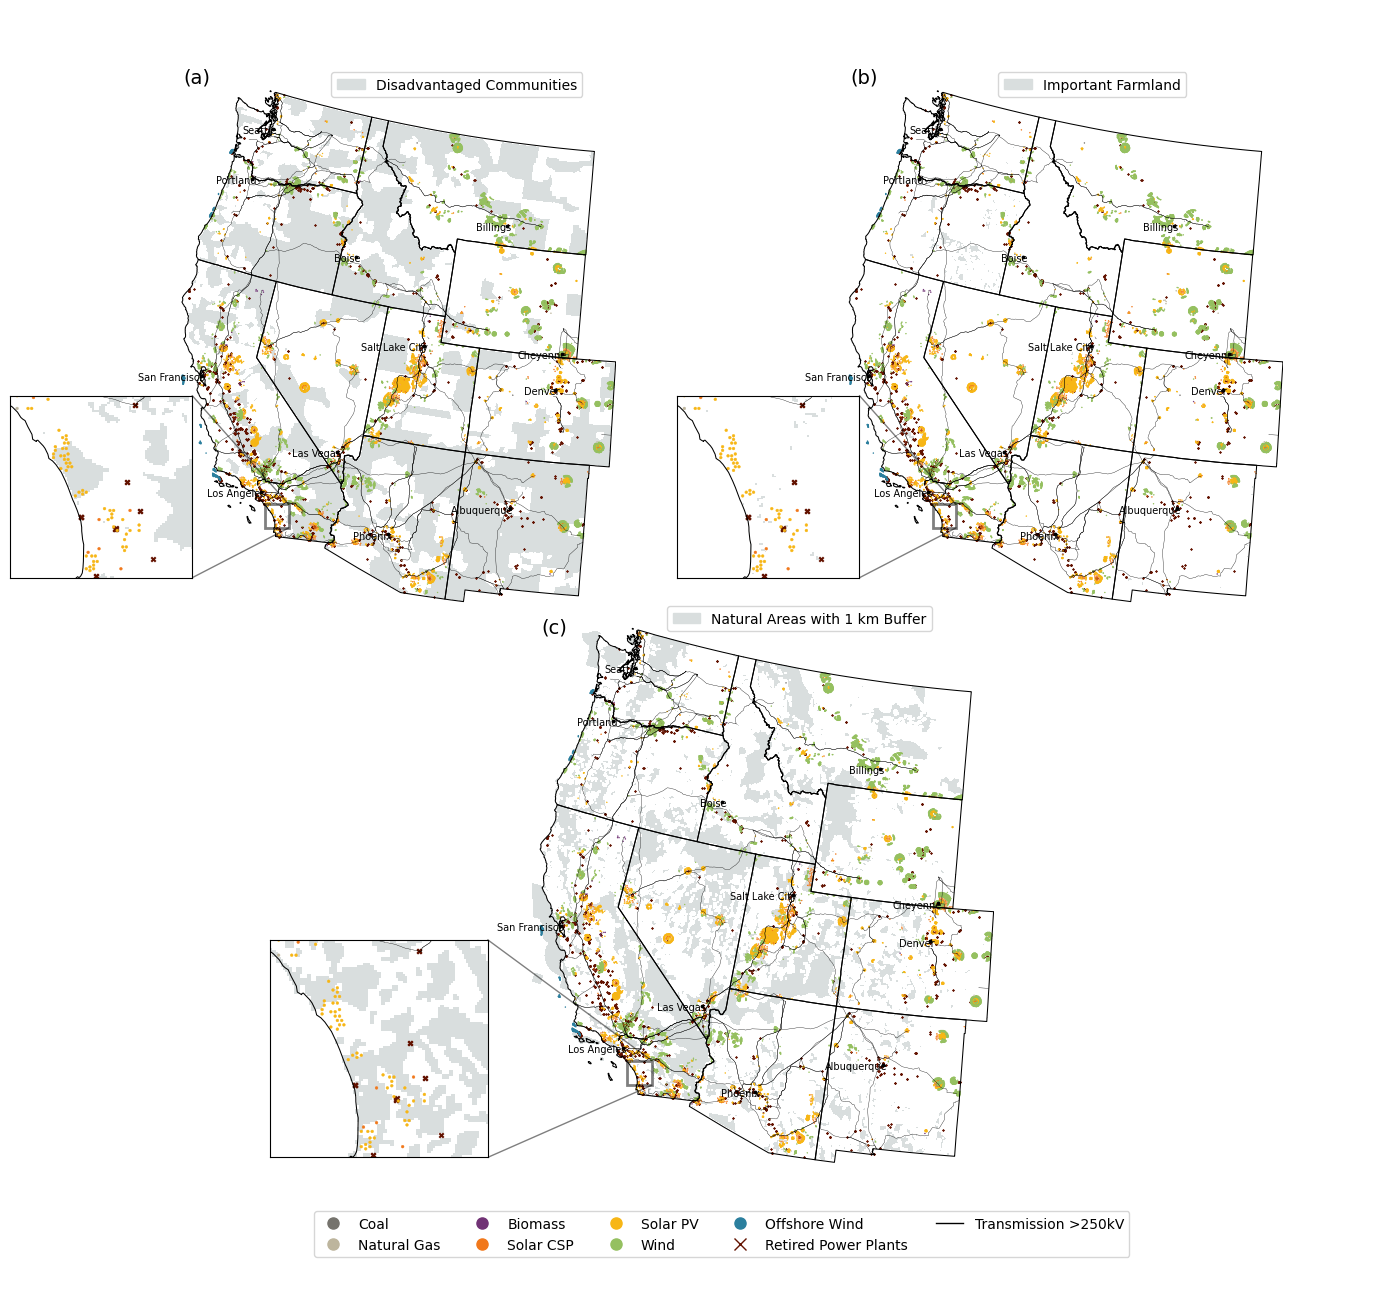

In [8]:
scenario = 'business_as_usual'

year = 2050

# figure plot
layer_list = [os.path.join(land_area_raster_dir, 'gridcerf_usceq_cejst_exclude_all_dacs.tif'), 
              os.path.join(land_area_raster_dir, 'gridcerf_usda_combined_important_farmland.tif'),
              os.path.join(all_area_raster_dir, 'gridcerf_combined_environment_level_1_1buff.tif')]

# create a layer patch for the layer name
legend_elements_copy = short_legend_elements.copy()

gdf_plot = gdf[gdf.scenario == scenario]

height = 13
width = 14

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=6, 
                nrows=4,
                width_ratios=[.15,.15, .15, .15 ,.15, .15], 
                wspace=0,
                hspace=0,
                height_ratios=[.05, .5, .5,.08])

ax_title = fig.add_subplot(spec[0,:])
ax1a =fig.add_subplot(spec[1,0:3])
ax1b =fig.add_subplot(spec[1,3:])
ax2a =fig.add_subplot(spec[2,1:5])
ax_legend = fig.add_subplot(spec[3,:])

ax_objs = [ax1a, ax1b, ax2a]
gdf_cerf = gdf_plot[(gdf_plot.cerf_sited == 1)]
gdf_all = gdf_plot.copy()
i = 0
for a in ax_objs:
    with rasterio.open(layer_list[i]) as src:
        show(src, ax=a, cmap=layer_cmap)
        wecc_shp.boundary.plot(ax=a, color = 'black', lw=.75)

         # plot retired plants
        gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
        gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
        gdf_ret_plot.plot(ax=a, markersize=.5, color=retired_color, marker="x")

        gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
        gdf_plot.plot(ax=a, markersize=.5,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))

        transmission_shp.plot(ax=a, color='black', lw=.25)
        city_gdf.plot(ax=a, color='black', markersize=3)
    
        # add city labels
        for x, y, label in zip(city_gdf.geometry.x, city_gdf.geometry.y, city_gdf.city):
            a.annotate(label, xy=(x, y), xytext=(3, -3), textcoords="offset points", ha='right', size=7)
        
    i+=1
    a.set_axis_off()
ax_legend.legend(handles=legend_elements_copy, fontsize=10, loc='center', ncol=5, facecolor='white')
ax_legend.set_axis_off()
ax_title.set_axis_off()

ax1a.annotate('(a)' , xy=(-2.35e6, 1.6e6), ha='left', size=14)
ax1b.annotate('(b)' , xy=(-2.35e6, 1.6e6), ha='left', size=14)
ax2a.annotate('(c)' , xy=(-2.35e6, 1.55e6), ha='left', size=14)


ax1a.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Disadvantaged Communities')], bbox_to_anchor=(.36, 1.0), )
ax1b.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Important Farmland')], bbox_to_anchor=(.36, 1.0), )
ax2a.legend(handles=[mpatches.Patch(color = suitable_color,label = 'Natural Areas with 1 km Buffer')], bbox_to_anchor=(.9, 1.05), )

plt.tight_layout()

# inset Axes
x1, x2, y1, y2 = -2e6, -1.9e6, -.3e6, -.2e6  # subregion of the original image
axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin1 = ax2a.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax2a.indicate_inset_zoom(axin1, edgecolor="black", lw=2) 

axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin2 = ax1a.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax1a.indicate_inset_zoom(axin2, edgecolor="black", lw=2) 

axin_placement = [-.33, .05, .4, .4] # x0, y0, width, height
axin3 = ax1b.inset_axes(axin_placement, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
ax1b.indicate_inset_zoom(axin3, edgecolor="black", lw=2) 

# top left axin
with rasterio.open(layer_list[0]) as src:
    show(src, ax=axin2, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin2, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin2, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin2, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin2, color='black', lw=.25)
axin2.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 

# top left axin
with rasterio.open(layer_list[1]) as src:
    show(src, ax=axin3, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin3, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin3, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin3, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin3, color='black', lw=.25)
axin3.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 


# bottom axin
with rasterio.open(layer_list[2]) as src:
    show(src, ax=axin1, cmap=layer_cmap)
    wecc_shp.boundary.plot(ax=axin1, color = 'black', lw=.75)
     # plot retired plants
    gdf_ret_plot = gdf_all[gdf_all.retirement_year <= year]
    gdf_ret_plot = gdf_ret_plot[gdf_ret_plot.region_name.isin(west_states)]
    gdf_ret_plot.plot(ax=axin1, markersize=10, color=retired_color, marker="x")
    gdf_plot = gdf_cerf[(gdf_cerf.sited_year <= year) & (gdf_cerf.retirement_year > year) ]
    gdf_plot.plot(ax=axin1, markersize=4,  marker = 'o', lw=.3, facecolor=gdf_plot['technology_simple'].map(color_map_dict))
    transmission_shp.plot(ax=axin1, color='black', lw=.25)
axin1.tick_params(bottom = False, left = False, top = False ,  labelleft = False ,  labelbottom = False,) 

output_file_name = 'fig_si-3_bau_sitings_and_layers_2050.png'
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, output_file_name), dpi=700)

plt.show()

___________ 